In [6]:
import json
import copy
import torch
import random
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset

from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [ ]:
# ---- CONFIG ----
# Global configuration container for model search, training, and threshold tuning.

CONFIG = {

    # ---- Hyperparameter Search Space ----
    # Defines candidate values for architecture selection / tuning
    "search_space": {
        # Hidden layer size for encoder/decoder LSTM
        "hidden_dim": [128],

        # Latent bottleneck dimensionality
        "latent_dim": [4],

        # Number of stacked LSTM layers
        "num_layers": [1],

        # Sliding window sequence lengths for time-series segmentation
        "seq_len": [64*2, 64*3, 64*4, 64*5, 64*6]
    },

    # ---- Training Configuration ----
    # Controls optimization and training stability behavior
    "train": {
        # Maximum training epochs per run
        "epochs": 50,

        # Mini-batch size for gradient updates
        "batch_size": 64,

        # Optimizer learning rate
        "lr": 1e-3,

        # Early stopping: epochs without improvement before stopping
        "early_stopping_patience": 10,

        # LR scheduler patience before decay trigger
        "scheduler_patience": 3,

        # Multiplicative decay factor for LR scheduler
        "scheduler_factor": 0.5,

        # Lower bound for learning rate decay
        "min_lr": 1e-6
    },

    # ---- Threshold Calibration ----
    # Percentile grid used to select anomaly detection threshold
    "threshold_percentiles": np.arange(30, 100, 1)
}

In [ ]:
# ---- MODEL ----
class LSTMAutoencoder(nn.Module):
    """
    LSTM Autoencoder for sequence reconstruction.
    Learns compact latent representation of time-series data.
    """

    def __init__(
        self,
        input_dim=1,
        hidden_dim=64,
        latent_dim=16,
        num_layers=1
    ):
        super().__init__()

        self.num_layers = num_layers

        # ---- Encoder ----
        # Maps input sequence → hidden representation
        self.encoder = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # ---- Latent Bottleneck ----
        # Compress encoder hidden state into latent space
        self.to_latent = nn.Linear(hidden_dim, latent_dim)

        # Expand latent vector back to decoder hidden space
        self.from_latent = nn.Linear(latent_dim, hidden_dim)

        # ---- Decoder ----
        # Reconstruct sequence from latent-conditioned input
        self.decoder = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # ---- Output Projection ----
        # Map decoder hidden states back to input feature space
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):

        # ---- Encode Sequence ----
        _, (h, _) = self.encoder(x)

        # Take last layer hidden state as sequence summary
        z = self.to_latent(h[-1])

        # ---- Latent Expansion ----
        # Convert latent vector into decoder initial representation
        h_dec = self.from_latent(z)

        # Sequence length for reconstruction
        seq_len = x.shape[1]

        # Repeat latent representation across time dimension
        dec_in = h_dec.unsqueeze(1).repeat(1, seq_len, 1)

        # Initialize decoder hidden state from latent vector
        h0 = h_dec.unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)

        # ---- Decode Sequence ----
        out, _ = self.decoder(dec_in, (h0, c0))

        # ---- Reconstruct Output ----
        return self.output_layer(out)

In [ ]:
# ---- DATA LOADING ----
# Responsible for reading raw time-series data, normalization,
# loading anomaly windows, and constructing supervised labels.

def load_series(path):
    # Read CSV and parse timestamps
    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Ensure chronological order for time-series consistency
    df = df.sort_values("timestamp").reset_index(drop=True)

    # Select only numerical features for modeling
    num_cols = df.select_dtypes(include=["number"]).columns

    # Standardize numerical features (zero mean, unit variance)
    df[num_cols] = (
        (df[num_cols] - df[num_cols].mean())
        / df[num_cols].std()
    )

    return df


def load_windows(path, key):
    # Load labeled anomaly intervals from JSON file
    with open(path, "r") as f:
        return json.load(f)[key]


def build_labels(df, windows):
    # Initialize binary label vector (0 = normal, 1 = anomaly)
    y = np.zeros(len(df))

    # Convert time windows into point-wise labels
    for s, e in windows:
        s = pd.to_datetime(s)
        e = pd.to_datetime(e)

        # Create mask for all timestamps within anomaly window
        mask = (
            (df["timestamp"] >= s) &
            (df["timestamp"] <= e)
        )

        y[mask] = 1

    # Attach labels to dataframe
    df["label"] = y

    return df

In [ ]:
# ---- WINDOWING ----
# Converts time-series into overlapping sliding windows for sequence modeling.
# Each window inherits a label based on presence of any anomaly inside it.

def make_windows(values, labels, seq_len):

    # Ensure consistent array format for slicing
    values = np.asarray(values).reshape(-1, 1)
    labels = np.asarray(labels)

    # Number of possible sliding windows
    n = len(values) - seq_len + 1

    # Pre-allocate tensors for efficiency
    x = np.zeros((n, seq_len, 1), dtype=np.float32)
    y = np.zeros(n, dtype=np.float32)

    # ---- Sliding Window Construction ----
    for i in range(n):
        # Input sequence window
        x[i] = values[i:i + seq_len]

        # Label aggregation (OR over window)
        # If any timestep is anomalous → window is anomalous
        y[i] = np.max(labels[i:i + seq_len])

    return x, y

In [ ]:
# ---- SPLIT ----
# Splits windowed dataset into train/validation/test indices.
# Strategy: train mostly normal data, while val/test include anomalies.

def split_windows(x, y):

    # Indices separated by class
    normal = np.where(y == 0)[0]
    anomaly = np.where(y == 1)[0]

    # Shuffle to avoid ordering bias
    np.random.shuffle(normal)
    np.random.shuffle(anomaly)

    # ---- Train Split (Normal Only) ----
    n_train = int(0.7 * len(normal))
    n_val = int(0.15 * len(normal))

    train_idx = normal[:n_train]

    # ---- Validation Split ----
    # Mix remaining normal + part of anomalies
    val_idx = np.concatenate([
        normal[n_train:n_train + n_val],
        anomaly[:len(anomaly) // 2]
    ])

    # ---- Test Split ----
    # Remaining normal + remaining anomalies
    test_idx = np.concatenate([
        normal[n_train + n_val:],
        anomaly[len(anomaly) // 2:]
    ])

    return train_idx, val_idx, test_idx

In [ ]:
# ---- METRICS ----
# Evaluates anomaly detection performance at a given threshold.
# Converts continuous anomaly scores into binary predictions.

def metrics(y_true, scores, thr):

    # ---- Thresholding ----
    # Convert anomaly scores into binary predictions
    pred = (scores > thr).astype(int)

    # ---- Classification Metrics ----
    # Precision: correctness of detected anomalies
    # Recall: coverage of actual anomalies
    # F1: harmonic mean of precision and recall
    return (
        precision_score(y_true, pred, zero_division=0),
        recall_score(y_true, pred, zero_division=0),
        f1_score(y_true, pred, zero_division=0)
    )

In [ ]:
# ---- SEED ----
# Ensures reproducibility across Python, NumPy, and PyTorch.

def set_seed(seed):

    # Python RNG seed
    random.seed(seed)

    # NumPy RNG seed
    np.random.seed(seed)

    # PyTorch CPU seed
    torch.manual_seed(seed)

    # PyTorch GPU seed (all devices)
    torch.cuda.manual_seed_all(seed)

In [ ]:
# ---- TRAIN ----
# Full training loop for LSTM Autoencoder with:
# - Adam optimizer
# - ReduceLROnPlateau scheduler
# - Early stopping
# - Best checkpoint restoration
# - Loss tracking and visualization

def train(model, x_train, x_val, device):

    # ---- Device Setup ----
    model = model.to(device)

    # ---- Optimizer ----
    opt = torch.optim.Adam(
        model.parameters(),
        lr=CONFIG["train"]["lr"]  # type: ignore
    )

    # ---- LR Scheduler ----
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        mode="min",
        factor=CONFIG["train"]["scheduler_factor"],  # type: ignore
        patience=CONFIG["train"]["scheduler_patience"],  # type: ignore
        min_lr=CONFIG["train"]["min_lr"]  # type: ignore
    )

    # ---- Loss Function ----
    loss_fn = nn.MSELoss()

    # ---- DataLoaders ----
    loader_tr = DataLoader(
        TensorDataset(torch.tensor(x_train)),
        batch_size=CONFIG["train"]["batch_size"],  # type: ignore
        shuffle=True
    )

    loader_va = DataLoader(
        TensorDataset(torch.tensor(x_val)),
        batch_size=CONFIG["train"]["batch_size"]  # type: ignore
    )

    # ---- Training State ----
    best_val = float("inf")
    best_state = None
    patience_counter = 0

    train_losses = []
    val_losses = []

    # ---- Training Loop ----
    for ep in range(CONFIG["train"]["epochs"]):  # type: ignore

        model.train()
        tr_loss = 0

        # ---- Train Step ----
        for (b,) in loader_tr:
            b = b.to(device)
            loss = loss_fn(model(b), b)

            opt.zero_grad()
            loss.backward()
            opt.step()

            tr_loss += loss.item()

        tr_loss = tr_loss / len(loader_tr)

        # ---- Validation Step ----
        model.eval()
        va_loss = 0

        with torch.no_grad():
            for (b,) in loader_va:
                b = b.to(device)
                va_loss += loss_fn(model(b), b).item()

        va_loss = va_loss / len(loader_va)

        # ---- Scheduler Step ----
        scheduler.step(va_loss)
        current_lr = opt.param_groups[0]["lr"]

        train_losses.append(tr_loss)
        val_losses.append(va_loss)

        print(
            f"Epoch {ep+1} | "
            f"train_loss={tr_loss:.5f} | "
            f"val_loss={va_loss:.5f} | "
            f"lr={current_lr:.7f}"
        )

        # ---- Checkpointing ----
        if va_loss < best_val:
            best_val = va_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0

        else:
            patience_counter += 1

            print(
                f"EarlyStopping Counter: "
                f"{patience_counter}/"
                f"{CONFIG['train']['early_stopping_patience']}"  # type: ignore
            )

            # ---- Early Stopping ----
            if patience_counter >= CONFIG["train"]["early_stopping_patience"]:  # type: ignore
                print("EARLY STOPPING TRIGGERED")
                break

    # ---- Restore Best Model ----
    if best_state is not None:
        model.load_state_dict(best_state)

    # ---- Training Curves ----
    plt.figure(figsize=(10, 4))
    plt.plot(train_losses, label="train_loss")
    plt.plot(val_losses, label="val_loss")
    plt.title("Loss Curve")
    plt.legend()
    plt.show()

    return model

In [ ]:
# ---- ERRORS ----
# Computes reconstruction error per sample using MSE.
# Used as anomaly score for threshold-based detection.

def get_errors(model, x, device):

    # ---- Eval Mode ----
    model.eval()

    # ---- Data Loader ----
    loader = DataLoader(
        TensorDataset(torch.tensor(x)),
        batch_size=256
    )

    errs = []

    # ---- No Gradient Inference ----
    with torch.no_grad():

        for (b,) in loader:

            b = b.to(device)

            # Forward pass (reconstruction)
            r = model(b)

            # ---- Per-sample reconstruction error ----
            # Mean over sequence length + feature dimension
            errs.append(
                torch.mean(
                    (r - b) ** 2,
                    dim=(1, 2)
                ).cpu()
            )

    # ---- Flatten results ----
    return torch.cat(errs).numpy()

In [ ]:
# ---- VISUALIZATION ----
# Displays:
# 1) Original signal with anomaly points
# 2) Reconstruction error with decision threshold

def plot_results(series, labels, errors, thr, title=""):

    # ---- Signal Plot ----
    plt.figure(figsize=(12, 4))

    plt.plot(series, label="signal")

    # Highlight ground-truth anomalies
    plt.scatter(
        np.where(labels == 1)[0],
        series[labels == 1],
        c="red",
        s=10,
        label="anomaly"
    )

    plt.title(f"{title} - Signal + Anomalies")
    plt.legend()
    plt.show()

    # ---- Error Plot ----
    plt.figure(figsize=(12, 4))

    plt.plot(errors, label="reconstruction error")

    # Decision threshold line
    plt.axhline(
        thr,
        color="red",
        linestyle="--",
        label="threshold"
    )

    plt.title(f"{title} - Error + Threshold")
    plt.legend()
    plt.show()

In [ ]:
# ---- EXPERIMENT ----
# Full pipeline experiment:
# 1) Windowing
# 2) Train/val/test split
# 3) Train LSTM autoencoder
# 4) Reconstruction error scoring
# 5) Threshold selection via validation F1
# 6) Final evaluation on test set
# 7) Baseline comparison with Isolation Forest
# 8) Visualization + metrics aggregation

def run_experiment(df, params, device):

    print("\n================ RUN =================")
    print(params)

    # ---- Windowing ----
    x, y = make_windows(
        df["value"].values,
        df["label"].values,
        params["seq_len"]
    )

    # ---- Split ----
    tr_idx, va_idx, te_idx = split_windows(x, y)

    x_tr = x[tr_idx]
    x_va = x[va_idx]
    y_va = y[va_idx]
    x_te = x[te_idx]
    y_te = y[te_idx]

    # Train only on normal samples (unsupervised constraint)
    x_tr = x_tr[y[tr_idx] == 0]

    # ---- Model ----
    model = LSTMAutoencoder(
        hidden_dim=params["hidden_dim"],
        latent_dim=params["latent_dim"],
        num_layers=params["num_layers"]
    )

    model = train(model, x_tr, x_va, device)

    # ---- Scoring ----
    tr_s = get_errors(model, x_tr, device)
    va_s = get_errors(model, x_va, device)
    te_s = get_errors(model, x_te, device)

    # ---- Threshold Search ----
    print("\n===== THRESHOLD SEARCH =====")
    best_t = 0
    best_f1 = -1

    for p in CONFIG["threshold_percentiles"]:
        t = np.percentile(va_s, p)  # type: ignore

        _, _, f1_v = metrics(y_va, va_s, t)

        print(
            f"p={p:.1f}% | "
            f"thr={t:.6f} | "
            f"F1={f1_v:.4f}"
        )

        if f1_v > best_f1:
            best_f1 = f1_v
            best_t = t

    print("\nBEST THRESHOLD:", best_t)

    # ---- Test Evaluation ----
    p, r, f1 = metrics(y_te, te_s, best_t)

    roc_auc = roc_auc_score(y_te, te_s)
    pr_auc = average_precision_score(y_te, te_s)

    print(
        f"\nTEST -> "
        f"P={p:.4f} "
        f"R={r:.4f} "
        f"F1={f1:.4f} "
        f"ROC_AUC={roc_auc:.4f} "
        f"PR_AUC={pr_auc:.4f}"
    )

    # ---- Isolation Forest Baseline ----
    print("\n===== ISOLATION FOREST =====")

    iso = IsolationForest(
        contamination=0.05,
        random_state=42
    )

    # Flatten sequences for classical model
    x_tr_flat = x_tr.reshape(len(x_tr), -1)
    x_te_flat = x_te.reshape(len(x_te), -1)

    iso.fit(x_tr_flat)

    iso_scores = -iso.decision_function(x_te_flat)

    iso_pred = np.where(
        iso.predict(x_te_flat) == -1,
        1,
        0
    )

    iso_p = precision_score(y_te, iso_pred, zero_division=0)
    iso_r = recall_score(y_te, iso_pred, zero_division=0)
    iso_f1 = f1_score(y_te, iso_pred, zero_division=0)

    iso_roc_auc = roc_auc_score(y_te, iso_scores)
    iso_pr_auc = average_precision_score(y_te, iso_scores)

    print(
        f"IF -> "
        f"P={iso_p:.4f} "
        f"R={iso_r:.4f} "
        f"F1={iso_f1:.4f} "
        f"ROC_AUC={iso_roc_auc:.4f} "
        f"PR_AUC={iso_pr_auc:.4f}"
    )

    # ---- Visualization ----
    plot_results(
        df["value"].values[:len(te_s)],
        y_te,
        te_s,
        best_t,
        title="TEST SET"
    )

    # ---- Return Metrics ----
    return {
        "hidden_dim": params["hidden_dim"],
        "latent_dim": params["latent_dim"],
        "num_layers": params["num_layers"],
        "seq_len": params["seq_len"],

        "threshold": best_t,

        "precision": p,
        "recall": r,
        "f1": f1,

        "roc_auc": roc_auc,
        "pr_auc": pr_auc,

        "if_precision": iso_p,
        "if_recall": iso_r,
        "if_f1": iso_f1,
        "if_roc_auc": iso_roc_auc,
        "if_pr_auc": iso_pr_auc
    }

In [ ]:
# ---- SEARCH ----
# Executes full hyperparameter grid search over defined search space.
# Each configuration runs full experiment pipeline and logs results.

def search(df, device):

    # ---- Parameter Grid ----
    # Extract search dimensions from CONFIG
    keys = list(CONFIG["search_space"].keys())  # type: ignore

    # Generate all combinations of hyperparameters
    combos = list(
        itertools.product(
            *CONFIG["search_space"].values()  # type: ignore
        )
    )

    results = []

    # ---- Grid Search Loop ----
    for i, vals in enumerate(combos):

        # Map tuple → parameter dictionary
        params = dict(zip(keys, vals))

        print(f"\n######## RUN {i+1}/{len(combos)} ########")

        # Execute full pipeline for this configuration
        res = run_experiment(df, params, device)

        results.append(res)

    # ---- Results Aggregation ----
    final_df = pd.DataFrame(results)

    # ---- Global Summary Row ----
    # Provides average performance across all configurations
    avg_row = {
        "hidden_dim": "AVG",
        "latent_dim": "-",
        "num_layers": "-",
        "seq_len": "-",

        "threshold": final_df["threshold"].mean(),

        "precision": final_df["precision"].mean(),
        "recall": final_df["recall"].mean(),
        "f1": final_df["f1"].mean(),

        "roc_auc": final_df["roc_auc"].mean(),
        "pr_auc": final_df["pr_auc"].mean(),

        # ---- Isolation Forest Baseline Averages ----
        "if_precision": final_df["if_precision"].mean(),
        "if_recall": final_df["if_recall"].mean(),
        "if_f1": final_df["if_f1"].mean(),
        "if_roc_auc": final_df["if_roc_auc"].mean(),
        "if_pr_auc": final_df["if_pr_auc"].mean()
    }

    # Append summary row
    final_df = pd.concat(
        [final_df, pd.DataFrame([avg_row])],
        ignore_index=True
    )

    # ---- Final Report ----
    print("\n================ FINAL SUMMARY =================")
    print(final_df)

    return final_df

DEVICE: cuda

######## RUN 1/5 ########

================ RUN =================
{'hidden_dim': 128, 'latent_dim': 4, 'num_layers': 1, 'seq_len': 128}
Epoch 1 | train_loss=0.98271 | val_loss=0.69837 | lr=0.0010000
Epoch 2 | train_loss=0.84474 | val_loss=0.73277 | lr=0.0010000
EarlyStopping Counter: 1/10
Epoch 3 | train_loss=0.82741 | val_loss=0.70281 | lr=0.0010000
EarlyStopping Counter: 2/10
Epoch 4 | train_loss=0.82225 | val_loss=0.69956 | lr=0.0010000
EarlyStopping Counter: 3/10
Epoch 5 | train_loss=0.81768 | val_loss=0.70412 | lr=0.0005000
EarlyStopping Counter: 4/10
Epoch 6 | train_loss=0.81720 | val_loss=0.69607 | lr=0.0005000
Epoch 7 | train_loss=0.82656 | val_loss=0.68695 | lr=0.0005000
Epoch 8 | train_loss=0.78619 | val_loss=0.86571 | lr=0.0005000
EarlyStopping Counter: 1/10
Epoch 9 | train_loss=0.73215 | val_loss=0.79622 | lr=0.0005000
EarlyStopping Counter: 2/10
Epoch 10 | train_loss=0.70863 | val_loss=0.62624 | lr=0.0005000
Epoch 11 | train_loss=0.69363 | val_loss=0.58969 | 

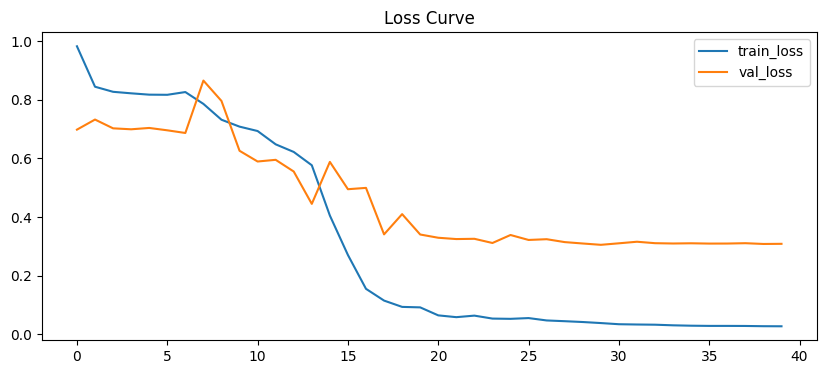


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.022677 | F1=0.5572
p=31.0% | thr=0.022917 | F1=0.5621
p=32.0% | thr=0.023377 | F1=0.5653
p=33.0% | thr=0.023641 | F1=0.5685
p=34.0% | thr=0.023906 | F1=0.5736
p=35.0% | thr=0.024443 | F1=0.5770
p=36.0% | thr=0.024853 | F1=0.5831
p=37.0% | thr=0.025058 | F1=0.5885
p=38.0% | thr=0.025332 | F1=0.5868
p=39.0% | thr=0.025664 | F1=0.5905
p=40.0% | thr=0.026226 | F1=0.5887
p=41.0% | thr=0.026652 | F1=0.5944
p=42.0% | thr=0.027215 | F1=0.5955
p=43.0% | thr=0.027705 | F1=0.6023
p=44.0% | thr=0.028059 | F1=0.6055
p=45.0% | thr=0.029032 | F1=0.6125
p=46.0% | thr=0.029616 | F1=0.6197
p=47.0% | thr=0.030641 | F1=0.6231
p=48.0% | thr=0.031102 | F1=0.6306
p=49.0% | thr=0.031817 | F1=0.6322
p=50.0% | thr=0.032364 | F1=0.6308
p=51.0% | thr=0.033214 | F1=0.6314
p=52.0% | thr=0.033588 | F1=0.6394
p=53.0% | thr=0.034292 | F1=0.6475
p=54.0% | thr=0.034741 | F1=0.6516
p=55.0% | thr=0.035412 | F1=0.6601
p=56.0% | thr=0.035942 | F1=0.6589
p=57.0% | thr=0.036530 | 

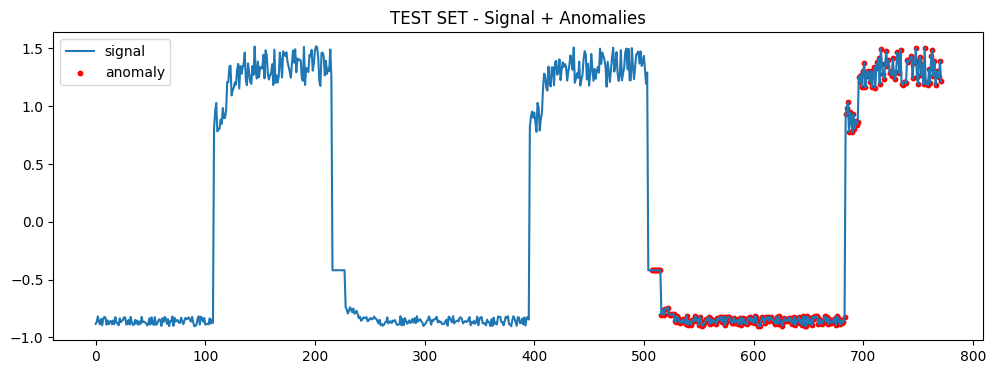

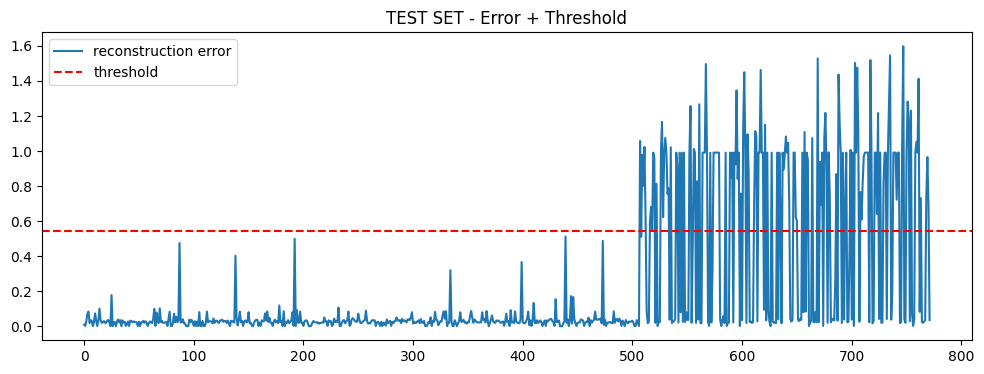


######## RUN 2/5 ########

================ RUN =================
{'hidden_dim': 128, 'latent_dim': 4, 'num_layers': 1, 'seq_len': 192}
Epoch 1 | train_loss=1.05153 | val_loss=0.89920 | lr=0.0010000
Epoch 2 | train_loss=1.04233 | val_loss=0.88999 | lr=0.0010000
Epoch 3 | train_loss=1.03084 | val_loss=0.87160 | lr=0.0010000
Epoch 4 | train_loss=0.97393 | val_loss=0.88690 | lr=0.0010000
EarlyStopping Counter: 1/10
Epoch 5 | train_loss=0.95235 | val_loss=0.89660 | lr=0.0010000
EarlyStopping Counter: 2/10
Epoch 6 | train_loss=0.94755 | val_loss=0.88496 | lr=0.0010000
EarlyStopping Counter: 3/10
Epoch 7 | train_loss=0.94370 | val_loss=0.91313 | lr=0.0005000
EarlyStopping Counter: 4/10
Epoch 8 | train_loss=0.93974 | val_loss=0.90611 | lr=0.0005000
EarlyStopping Counter: 5/10
Epoch 9 | train_loss=0.92922 | val_loss=0.91231 | lr=0.0005000
EarlyStopping Counter: 6/10
Epoch 10 | train_loss=0.93267 | val_loss=0.92917 | lr=0.0005000
EarlyStopping Counter: 7/10
Epoch 11 | train_loss=0.94354 | val_

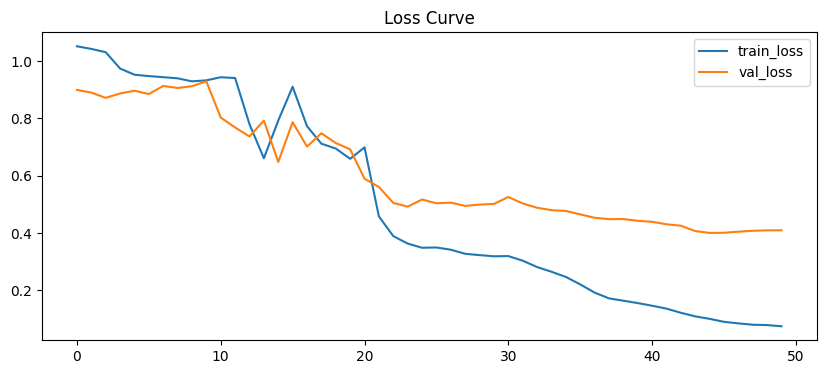


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.042035 | F1=0.5934
p=31.0% | thr=0.043006 | F1=0.5967
p=32.0% | thr=0.044847 | F1=0.6024
p=33.0% | thr=0.046748 | F1=0.6034
p=34.0% | thr=0.048727 | F1=0.6093
p=35.0% | thr=0.049713 | F1=0.6154
p=36.0% | thr=0.050996 | F1=0.6208
p=37.0% | thr=0.052122 | F1=0.6271
p=38.0% | thr=0.053903 | F1=0.6309
p=39.0% | thr=0.055284 | F1=0.6348
p=40.0% | thr=0.056630 | F1=0.6415
p=41.0% | thr=0.058452 | F1=0.6456
p=42.0% | thr=0.060515 | F1=0.6489
p=43.0% | thr=0.062266 | F1=0.6559
p=44.0% | thr=0.064091 | F1=0.6603
p=45.0% | thr=0.067095 | F1=0.6676
p=46.0% | thr=0.071516 | F1=0.6722
p=47.0% | thr=0.080014 | F1=0.6770
p=48.0% | thr=0.087606 | F1=0.6780
p=49.0% | thr=0.099099 | F1=0.6801
p=50.0% | thr=0.107864 | F1=0.6851
p=51.0% | thr=0.112778 | F1=0.6902
p=52.0% | thr=0.117039 | F1=0.6954
p=53.0% | thr=0.129353 | F1=0.6967
p=54.0% | thr=0.135133 | F1=0.6960
p=55.0% | thr=0.142764 | F1=0.7015
p=56.0% | thr=0.146094 | F1=0.7040
p=57.0% | thr=0.150001 | 

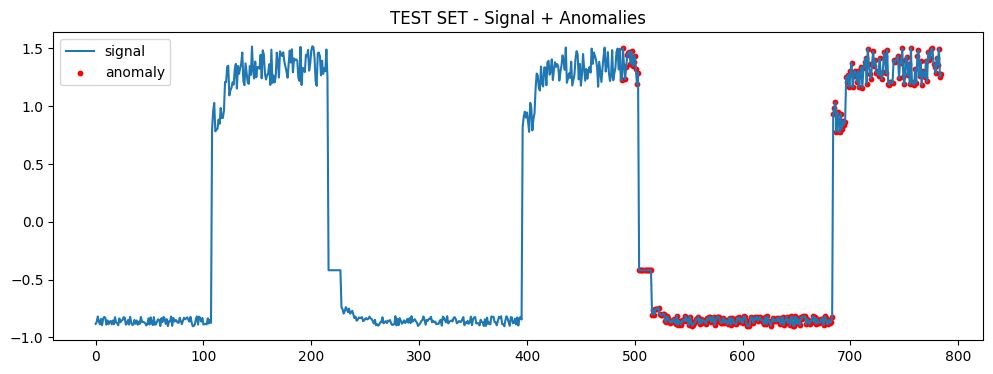

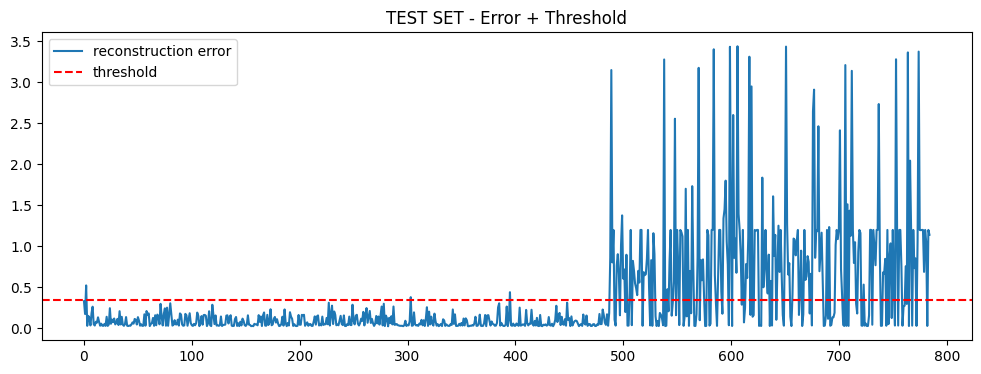


######## RUN 3/5 ########

================ RUN =================
{'hidden_dim': 128, 'latent_dim': 4, 'num_layers': 1, 'seq_len': 256}
Epoch 1 | train_loss=1.05229 | val_loss=0.90419 | lr=0.0010000
Epoch 2 | train_loss=1.04747 | val_loss=0.93762 | lr=0.0010000
EarlyStopping Counter: 1/10
Epoch 3 | train_loss=1.05073 | val_loss=0.90369 | lr=0.0010000
Epoch 4 | train_loss=1.05252 | val_loss=0.91517 | lr=0.0010000
EarlyStopping Counter: 1/10
Epoch 5 | train_loss=1.04755 | val_loss=0.91153 | lr=0.0010000
EarlyStopping Counter: 2/10
Epoch 6 | train_loss=1.04676 | val_loss=0.90469 | lr=0.0010000
EarlyStopping Counter: 3/10
Epoch 7 | train_loss=1.04538 | val_loss=0.89342 | lr=0.0010000
Epoch 8 | train_loss=1.03305 | val_loss=0.90063 | lr=0.0010000
EarlyStopping Counter: 1/10
Epoch 9 | train_loss=1.02767 | val_loss=0.89002 | lr=0.0010000
Epoch 10 | train_loss=1.02044 | val_loss=0.90827 | lr=0.0010000
EarlyStopping Counter: 1/10
Epoch 11 | train_loss=1.03837 | val_loss=0.89057 | lr=0.0010000


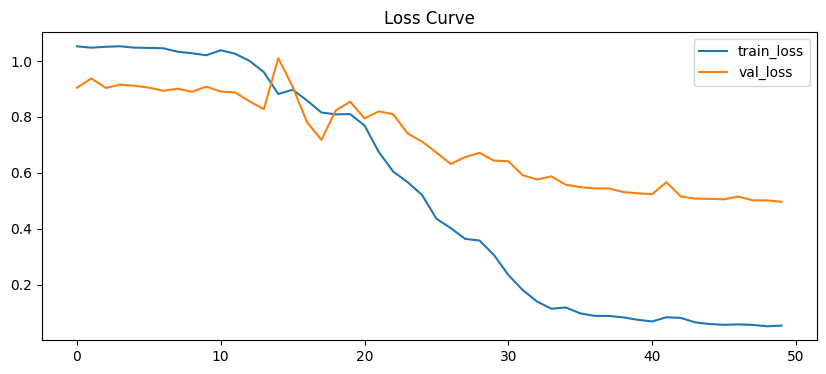


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.041026 | F1=0.6479
p=31.0% | thr=0.041434 | F1=0.6469
p=32.0% | thr=0.041683 | F1=0.6460
p=33.0% | thr=0.042031 | F1=0.6450
p=34.0% | thr=0.042203 | F1=0.6487
p=35.0% | thr=0.042509 | F1=0.6525
p=36.0% | thr=0.042704 | F1=0.6516
p=37.0% | thr=0.043010 | F1=0.6530
p=38.0% | thr=0.043496 | F1=0.6545
p=39.0% | thr=0.043737 | F1=0.6609
p=40.0% | thr=0.044346 | F1=0.6650
p=41.0% | thr=0.044704 | F1=0.6708
p=42.0% | thr=0.045215 | F1=0.6751
p=43.0% | thr=0.045579 | F1=0.6743
p=44.0% | thr=0.046399 | F1=0.6787
p=45.0% | thr=0.046660 | F1=0.6832
p=46.0% | thr=0.047167 | F1=0.6877
p=47.0% | thr=0.047440 | F1=0.6951
p=48.0% | thr=0.048097 | F1=0.7026
p=49.0% | thr=0.048733 | F1=0.7075
p=50.0% | thr=0.049157 | F1=0.7098
p=51.0% | thr=0.049718 | F1=0.7121
p=52.0% | thr=0.050513 | F1=0.7145
p=53.0% | thr=0.051594 | F1=0.7226
p=54.0% | thr=0.052110 | F1=0.7281
p=55.0% | thr=0.052807 | F1=0.7307
p=56.0% | thr=0.053651 | F1=0.7364
p=57.0% | thr=0.054290 | 

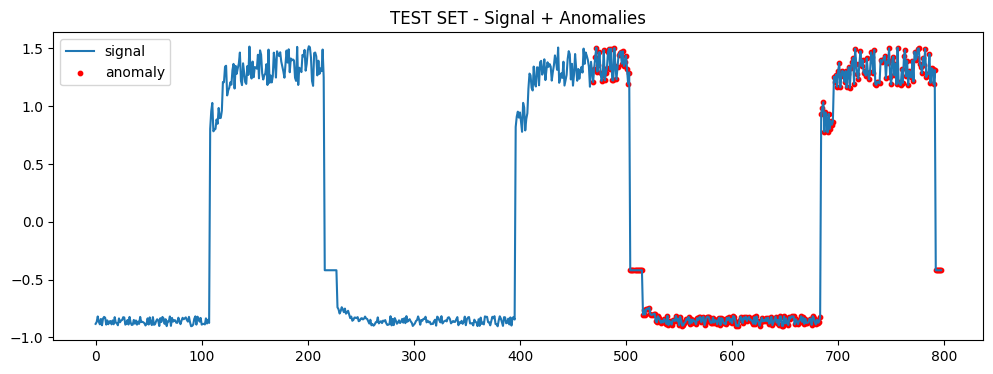

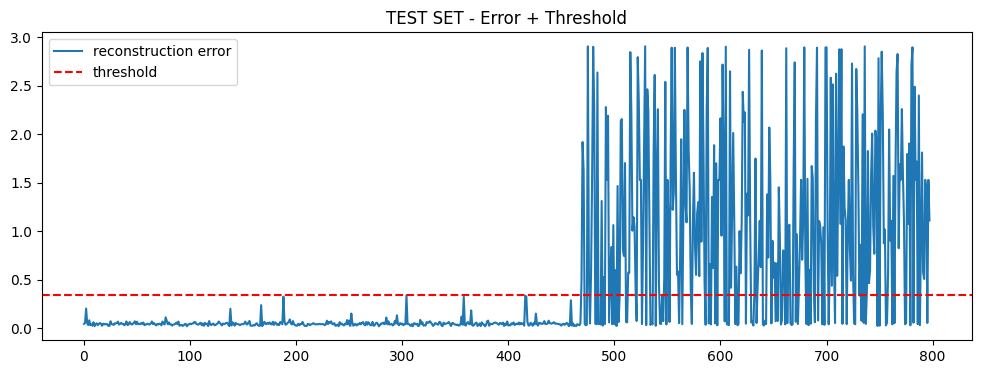


######## RUN 4/5 ########

================ RUN =================
{'hidden_dim': 128, 'latent_dim': 4, 'num_layers': 1, 'seq_len': 320}
Epoch 1 | train_loss=1.05289 | val_loss=0.91374 | lr=0.0010000
Epoch 2 | train_loss=1.04692 | val_loss=0.90261 | lr=0.0010000
Epoch 3 | train_loss=1.05018 | val_loss=0.89281 | lr=0.0010000
Epoch 4 | train_loss=1.04414 | val_loss=0.91069 | lr=0.0010000
EarlyStopping Counter: 1/10
Epoch 5 | train_loss=1.02256 | val_loss=0.90004 | lr=0.0010000
EarlyStopping Counter: 2/10
Epoch 6 | train_loss=0.97197 | val_loss=0.89931 | lr=0.0010000
EarlyStopping Counter: 3/10
Epoch 7 | train_loss=0.96523 | val_loss=0.88033 | lr=0.0010000
Epoch 8 | train_loss=0.95581 | val_loss=0.88908 | lr=0.0010000
EarlyStopping Counter: 1/10
Epoch 9 | train_loss=0.94793 | val_loss=0.89951 | lr=0.0010000
EarlyStopping Counter: 2/10
Epoch 10 | train_loss=0.95885 | val_loss=0.86032 | lr=0.0010000
Epoch 11 | train_loss=0.94546 | val_loss=0.89955 | lr=0.0010000
EarlyStopping Counter: 1/10


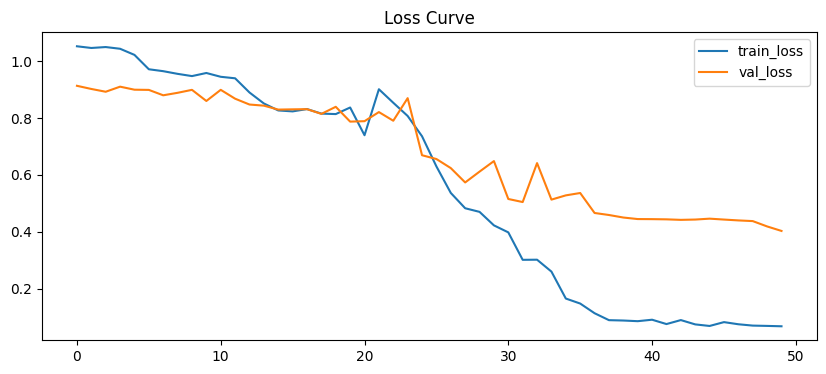


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.042280 | F1=0.7033
p=31.0% | thr=0.044247 | F1=0.7051
p=32.0% | thr=0.046274 | F1=0.7047
p=33.0% | thr=0.047200 | F1=0.7043
p=34.0% | thr=0.048359 | F1=0.7061
p=35.0% | thr=0.050361 | F1=0.7103
p=36.0% | thr=0.052007 | F1=0.7122
p=37.0% | thr=0.053743 | F1=0.7164
p=38.0% | thr=0.054928 | F1=0.7216
p=39.0% | thr=0.055782 | F1=0.7260
p=40.0% | thr=0.056715 | F1=0.7281
p=41.0% | thr=0.058012 | F1=0.7279
p=42.0% | thr=0.059143 | F1=0.7301
p=43.0% | thr=0.059554 | F1=0.7348
p=44.0% | thr=0.060431 | F1=0.7371
p=45.0% | thr=0.061493 | F1=0.7395
p=46.0% | thr=0.062221 | F1=0.7419
p=47.0% | thr=0.063413 | F1=0.7443
p=48.0% | thr=0.064767 | F1=0.7468
p=49.0% | thr=0.065600 | F1=0.7494
p=50.0% | thr=0.066659 | F1=0.7529
p=51.0% | thr=0.068591 | F1=0.7583
p=52.0% | thr=0.069590 | F1=0.7664
p=53.0% | thr=0.070972 | F1=0.7692
p=54.0% | thr=0.075389 | F1=0.7694
p=55.0% | thr=0.079550 | F1=0.7697
p=56.0% | thr=0.083932 | F1=0.7782
p=57.0% | thr=0.088879 | 

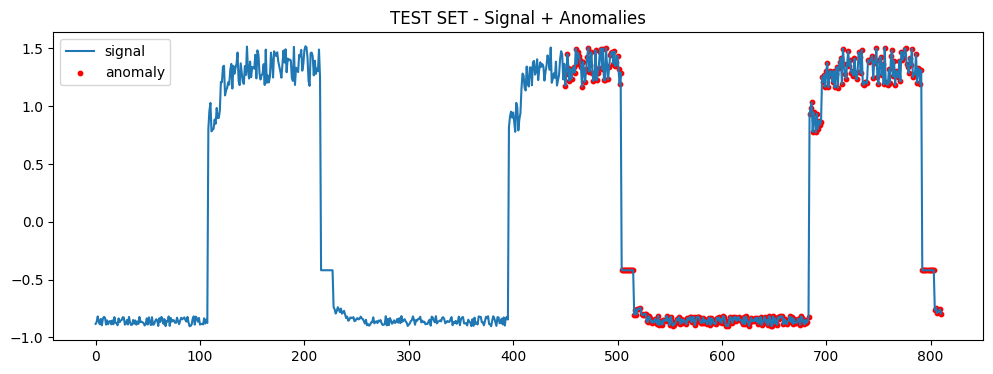

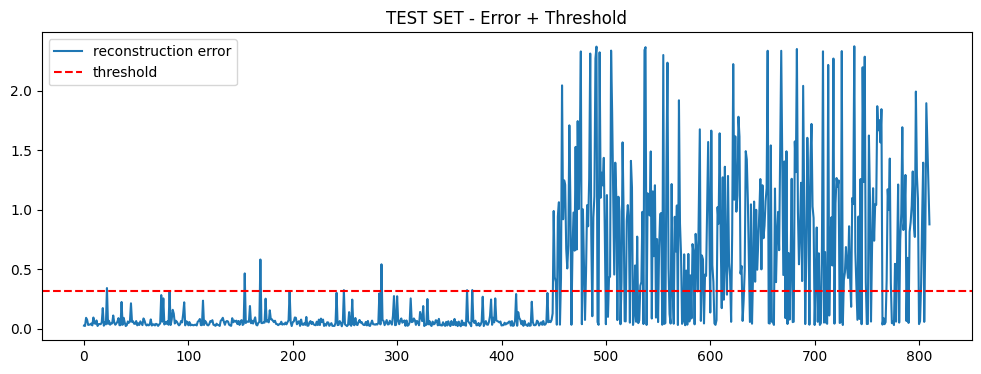


######## RUN 5/5 ########

================ RUN =================
{'hidden_dim': 128, 'latent_dim': 4, 'num_layers': 1, 'seq_len': 384}
Epoch 1 | train_loss=1.05204 | val_loss=0.90294 | lr=0.0010000
Epoch 2 | train_loss=1.03765 | val_loss=0.91176 | lr=0.0010000
EarlyStopping Counter: 1/10
Epoch 3 | train_loss=1.03243 | val_loss=0.88606 | lr=0.0010000
Epoch 4 | train_loss=1.02485 | val_loss=0.89263 | lr=0.0010000
EarlyStopping Counter: 1/10
Epoch 5 | train_loss=1.02291 | val_loss=0.88098 | lr=0.0010000
Epoch 6 | train_loss=1.02160 | val_loss=0.87802 | lr=0.0010000
Epoch 7 | train_loss=1.02391 | val_loss=0.88229 | lr=0.0010000
EarlyStopping Counter: 1/10
Epoch 8 | train_loss=1.02601 | val_loss=0.88484 | lr=0.0010000
EarlyStopping Counter: 2/10
Epoch 9 | train_loss=1.02478 | val_loss=0.90738 | lr=0.0010000
EarlyStopping Counter: 3/10
Epoch 10 | train_loss=1.02177 | val_loss=0.88293 | lr=0.0005000
EarlyStopping Counter: 4/10
Epoch 11 | train_loss=1.02179 | val_loss=0.91643 | lr=0.0005000


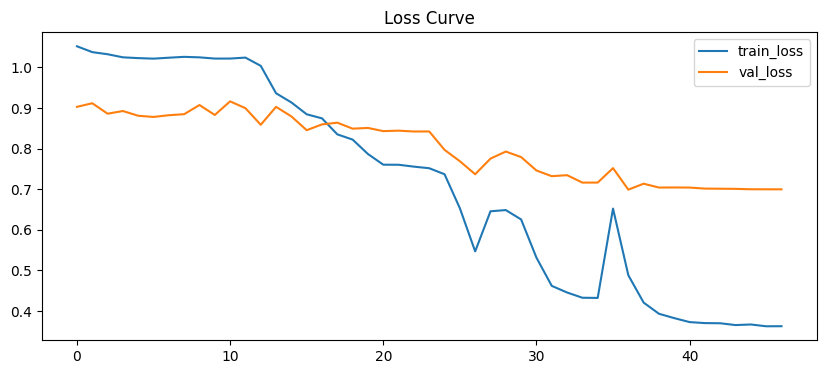


===== THRESHOLD SEARCH =====
p=30.0% | thr=0.299926 | F1=0.6921
p=31.0% | thr=0.339044 | F1=0.6875
p=32.0% | thr=0.356570 | F1=0.6891
p=33.0% | thr=0.372995 | F1=0.6843
p=34.0% | thr=0.397950 | F1=0.6824
p=35.0% | thr=0.410006 | F1=0.6796
p=36.0% | thr=0.418445 | F1=0.6768
p=37.0% | thr=0.433113 | F1=0.6718
p=38.0% | thr=0.441079 | F1=0.6711
p=39.0% | thr=0.455819 | F1=0.6622
p=40.0% | thr=0.476300 | F1=0.6524
p=41.0% | thr=0.490553 | F1=0.6446
p=42.0% | thr=0.505893 | F1=0.6460
p=43.0% | thr=0.530553 | F1=0.6481
p=44.0% | thr=0.545879 | F1=0.6424
p=45.0% | thr=0.559055 | F1=0.6367
p=46.0% | thr=0.566676 | F1=0.6332
p=47.0% | thr=0.578150 | F1=0.6273
p=48.0% | thr=0.591383 | F1=0.6268
p=49.0% | thr=0.613050 | F1=0.6207
p=50.0% | thr=0.629487 | F1=0.6119
p=51.0% | thr=0.640630 | F1=0.6055
p=52.0% | thr=0.651789 | F1=0.5939
p=53.0% | thr=0.668221 | F1=0.5854
p=54.0% | thr=0.681613 | F1=0.5785
p=55.0% | thr=0.696059 | F1=0.5793
p=56.0% | thr=0.707015 | F1=0.5748
p=57.0% | thr=0.723800 | 

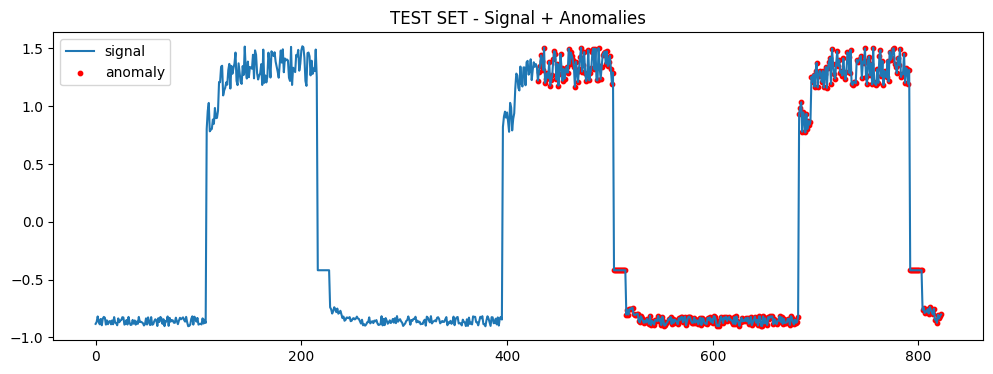

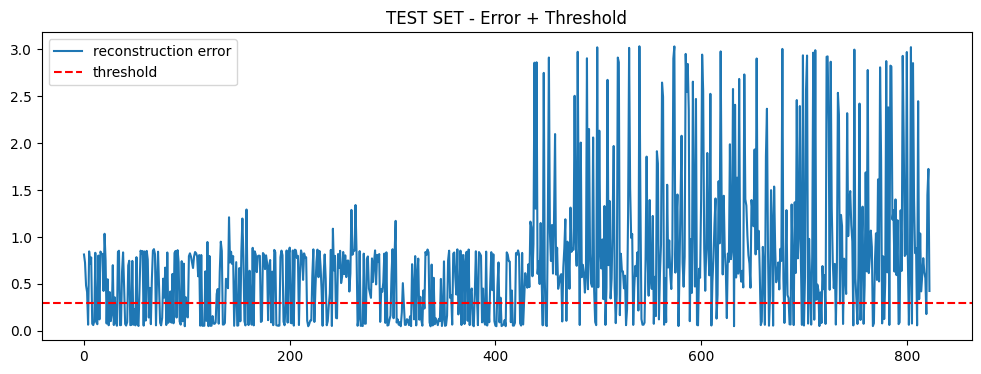


================ FINAL SUMMARY =================
  hidden_dim latent_dim num_layers seq_len  threshold  precision    recall  \
0        128          4          1     128   0.544364   1.000000  0.569811   
1        128          4          1     192   0.347886   0.984848  0.656566   
2        128          4          1     256   0.339277   1.000000  0.705167   
3        128          4          1     320   0.321640   0.973978  0.725762   
4        128          4          1     384   0.299926   0.566957  0.829517   
5        AVG          -          -       -   0.370619   0.905157  0.697364   

         f1   roc_auc    pr_auc  if_precision  if_recall     if_f1  \
0  0.725962  0.812400  0.806830      0.868852   0.600000  0.709821   
1  0.787879  0.815870  0.847043      0.902326   0.653199  0.757812   
2  0.827094  0.864019  0.885711      0.898438   0.699088  0.786325   
3  0.831746  0.882844  0.903188      0.920290   0.703601  0.797488   
4  0.673554  0.701355  0.748981      0.921824   0.720

In [ ]:
# ---- MAIN ----
# Entry point for full anomaly detection pipeline:
# - Device selection (CPU/GPU)
# - Reproducibility setup
# - Data loading
# - Label construction
# - Hyperparameter search execution

if __name__ == "__main__":

    # ---- Device Selection ----
    device = (
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    print("DEVICE:", device)

    # ---- Reproducibility ----
    set_seed(42)

    # ---- Load Time-Series Data ----
    df = load_series(
        "../assets/data/art_daily_flatmiddle.csv"
    )

    # ---- Load Anomaly Windows ----
    windows = load_windows(
        "../assets/labels/combined_windows.json",
        "artificialWithAnomaly/art_daily_flatmiddle.csv"
    )

    # ---- Build Ground Truth Labels ----
    df = build_labels(df, windows)

    # ---- Run Full Hyperparameter Search ----
    final_results = search(df, device)